# Method Comparison

Loads `outputs/comparison/results.csv` produced by `scripts/benchmark.py` and
compares accuracy, deployment cost, and training curves across methods.

In [1]:
import os
import sys
import json

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
os.chdir(ROOT)
sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from scripts.config import DEFAULTS
from src.utils.plot import show_history, show_samples
from src.core.factory import get_wrapper, get_samples
from src.utils.io import load_model

In [2]:
results = pd.read_csv(os.path.join("outputs", "comparison", "results.csv"))
results

,method,iou,mcd,max_cd,reproj_error,pck@0.02,pck@0.05,sr,cpu_latency_ms,gpu_latency_ms,params,size_mb
0,direct,0.7344,0.0623,0.0909,0.0552,0.0,0.0,1.0,50.0827,7.8731,23524424,89.9416


## Accuracy metrics

IoU / PCK / SR are higher-is-better; MCD / MaxCD / ReprojError are lower-is-better.
Accuracy metrics are read together with SR (success rate).

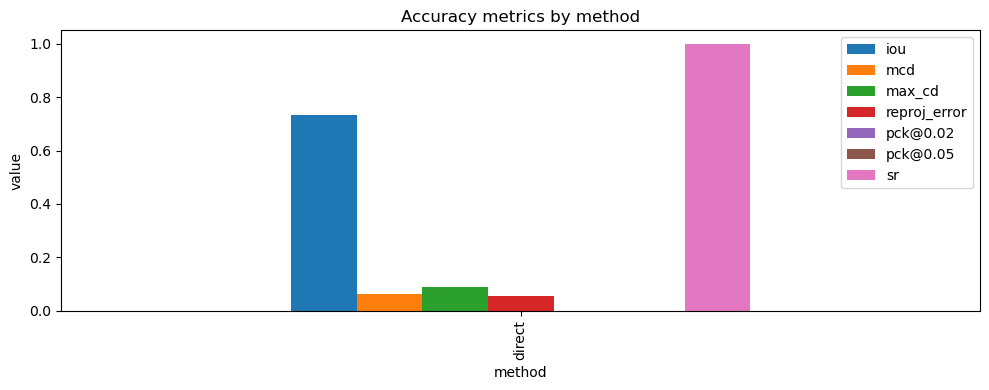

In [3]:
acc_cols = [c for c in ["iou", "mcd", "max_cd", "reproj_error", "pck@0.02", "pck@0.05", "sr"] if c in results.columns]
ax = results.set_index("method")[acc_cols].plot.bar(figsize=(10, 4))
ax.set_title("Accuracy metrics by method")
ax.set_ylabel("value")
plt.tight_layout()
plt.show()

## Deployment cost

GPU/CPU latency (ms per batch) and model size (parameters, MB), all lower-is-better.

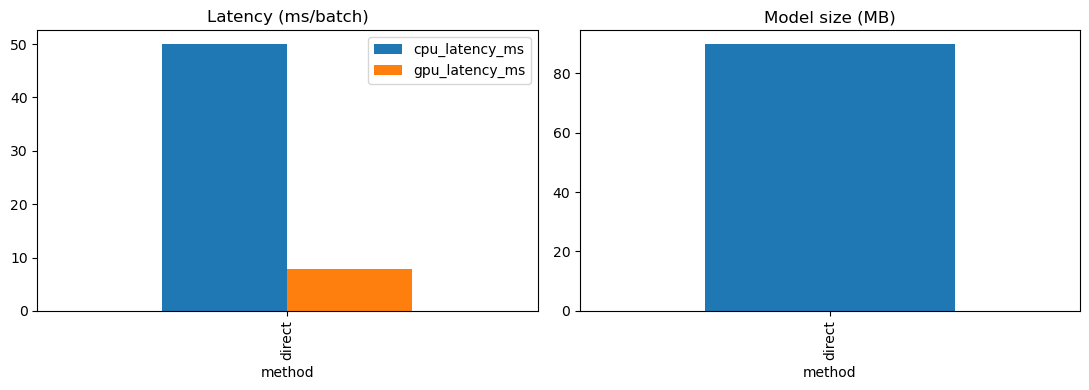

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lat_cols = [c for c in ["cpu_latency_ms", "gpu_latency_ms"] if c in results.columns]
results.set_index("method")[lat_cols].plot.bar(ax=axes[0], title="Latency (ms/batch)")
results.set_index("method")["size_mb"].plot.bar(ax=axes[1], title="Model size (MB)")
plt.tight_layout()
plt.show()

## Training curves

Reads `outputs/<method>/<experiment>/history.json` for each benchmarked config.

In [ ]:
for _, row in results.iterrows():
    output_dir = os.path.join("outputs", row["method"], row["experiment"])
    history_path = os.path.join(output_dir, "history.json")
    if not os.path.exists(history_path):
        continue
    with open(history_path, encoding="utf-8") as f:
        history = json.load(f)
    show_history(history, title=row["experiment"])

## Prediction visualization

Overlays predicted corners on validation samples for a chosen method.

In [ ]:
method = "direct"
image_size = DEFAULTS["image_size"]
experiment = results[results["method"] == method]["experiment"].iloc[0]

wrapper = get_wrapper(method)
load_model(wrapper.model, os.path.join("outputs", method, experiment, "model.pth"))
images, gt_corners = get_samples("valid", DEFAULTS["csv_path"], image_size=image_size, num_samples=10)
preds = torch.from_numpy(wrapper.predict_step(images))
show_samples(images, preds, ncols=5, title="%s predictions" % method, denormalize=True)